# Day 12: Cluster Validation
Do "Backend Developers" actually cluster together?
If yes → embeddings are meaningful → matcher will be trustworthy.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import silhouette_samples, confusion_matrix

BASE   = Path("../data/processed")
emp_df = pd.read_csv(BASE / "employees_clustered.csv", index_col=0)

print(f"Employees: {len(emp_df)}")
print(f"Clusters : {emp_df['cluster'].nunique()}")
print(f"\nCluster sizes:")
print(emp_df["cluster"].value_counts().sort_index())

Employees: 80
Clusters : 7

Cluster sizes:
cluster
0    16
1    10
2    11
3    20
4     5
5     9
6     9
Name: count, dtype: int64


## 1. Role Purity per Cluster

In [2]:
# What is the dominant role in each cluster?
cluster_summary = []
for c in sorted(emp_df["cluster"].unique()):
    subset      = emp_df[emp_df["cluster"] == c]
    top_role    = subset["role"].mode()[0]
    purity      = (subset["role"] == top_role).mean()
    cluster_summary.append({
        "cluster":      c,
        "size":         len(subset),
        "dominant_role": top_role,
        "purity_%":     round(purity * 100, 1),
        "roles_present": subset["role"].nunique(),
    })

summary_df = pd.DataFrame(cluster_summary)
print("Cluster Summary:")
print(summary_df.to_string(index=False))
print(f"\nAverage purity: {summary_df['purity_%'].mean():.1f}%")

Cluster Summary:
 cluster  size  dominant_role  purity_%  roles_present
       0    16    Backend Dev     100.0              1
       1    10    ML Engineer     100.0              1
       2    11 Full Stack Dev     100.0              1
       3    20  Data Engineer      60.0              3
       4     5    Android Dev     100.0              1
       5     9         DevOps     100.0              1
       6     9   Frontend Dev     100.0              1

Average purity: 94.3%


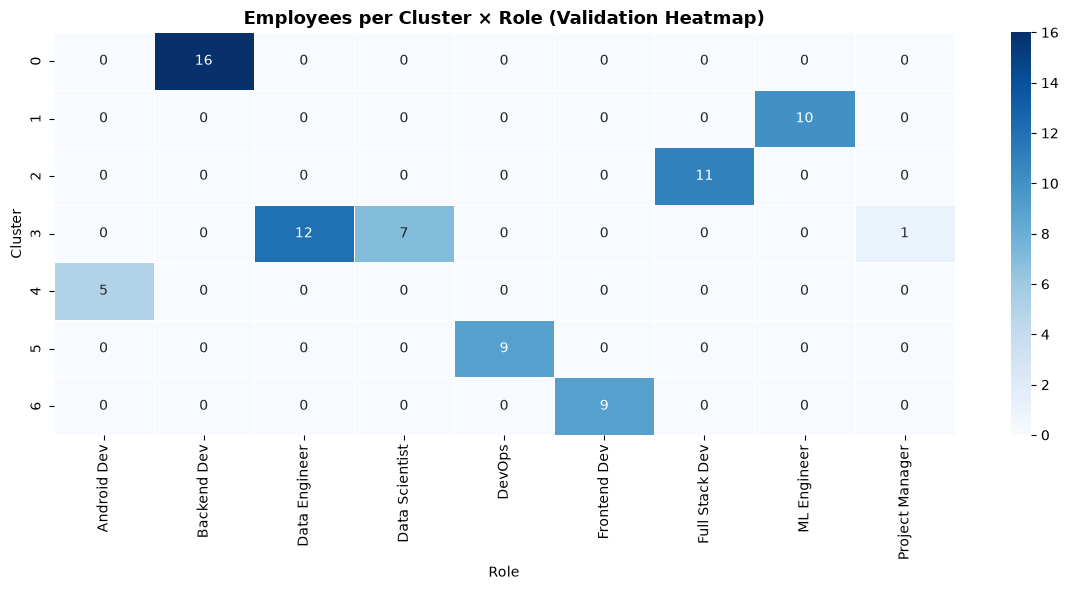

In [3]:
# Heatmap: cluster × role counts
pivot = emp_df.groupby(["cluster","role"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=ax)
ax.set_title("Employees per Cluster × Role (Validation Heatmap)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Role"); ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("../data/processed/day12_cluster_role_heatmap.png", dpi=150)
plt.show()

## 2. Within-Cluster Skill Analysis

In [4]:
from collections import Counter

for c in sorted(emp_df["cluster"].unique()):
    subset = emp_df[emp_df["cluster"] == c]
    all_skills = []
    for s in subset["skills"]:
        all_skills.extend([x.strip() for x in s.split(";")])
    top5 = Counter(all_skills).most_common(5)
    dominant = subset["role"].mode()[0]
    print(f"Cluster {c} [{dominant}] top skills: "
          + ", ".join(f"{s}({n})" for s, n in top5))

Cluster 0 [Backend Dev] top skills: Python(16), REST APIs(16), PostgreSQL(16), Docker(16), Agile/Scrum(12)
Cluster 1 [ML Engineer] top skills: Python(10), scikit-learn(10), pandas(10), NumPy(10), Git(7)
Cluster 2 [Full Stack Dev] top skills: JavaScript(11), React(11), Node.js(11), PostgreSQL(11), Agile/Scrum(9)
Cluster 3 [Data Engineer] top skills: Python(19), SQL(19), pandas(19), Git(18), AWS(14)
Cluster 4 [Android Dev] top skills: Android(5), Kotlin(5), Java(5), REST APIs(5), Git(5)
Cluster 5 [DevOps] top skills: Docker(9), Kubernetes(9), Linux(9), CI/CD(9), Git(7)
Cluster 6 [Frontend Dev] top skills: JavaScript(9), React(9), TypeScript(9), CSS(9), Git(9)


## 3. Silhouette Score per Employee

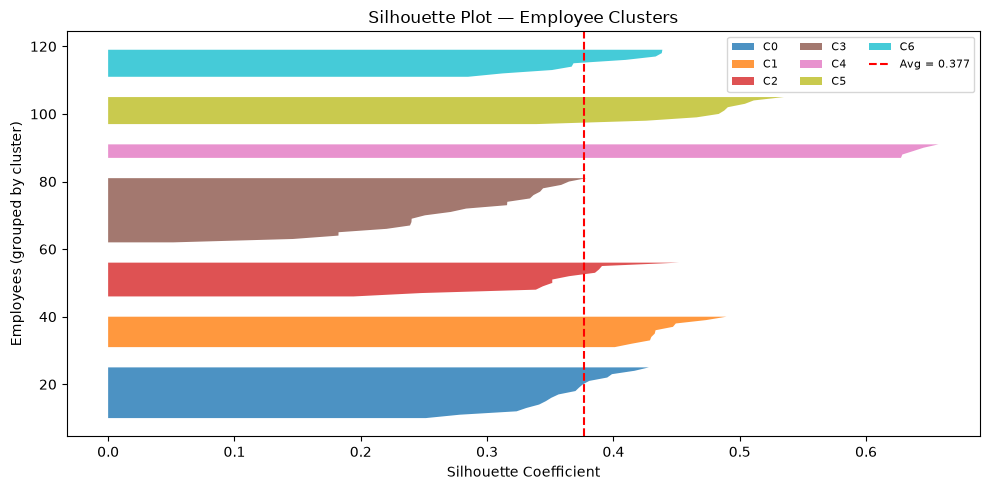

Overall silhouette score: 0.3771


In [5]:
embeddings = np.load(BASE / "employee_embeddings.npy")
labels     = emp_df["cluster"].values

from sklearn.metrics import silhouette_samples, silhouette_score
sil_vals   = silhouette_samples(embeddings, labels)
sil_avg    = silhouette_score(embeddings, labels)

emp_df["silhouette"] = sil_vals

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, emp_df["cluster"].nunique()))
y_lower = 10
for c in sorted(emp_df["cluster"].unique()):
    vals   = np.sort(sil_vals[labels == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[c], alpha=0.8, label=f"C{c}")
    y_lower = y_upper + 5

ax.axvline(sil_avg, color="red", linestyle="--",
           label=f"Avg = {sil_avg:.3f}")
ax.set_title("Silhouette Plot — Employee Clusters", fontsize=12)
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Employees (grouped by cluster)")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig("../data/processed/day12_silhouette_plot.png", dpi=150)
plt.show()
print(f"Overall silhouette score: {sil_avg:.4f}")

## ✅ Day 12 Validation Notes
- If purity > 60%: embeddings are capturing role semantics ✅
- If silhouette > 0.15: clusters are meaningfully separated ✅
- Insight: clusters will speed up candidate search in matcher.py
  (search within the right cluster first, then broaden if needed)